In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from src.io import resolve_relative_path, resolve_output_path

### Load the interim processed data generated in notebook 01

In [2]:
daily_station_climate = pd.read_csv(
    resolve_relative_path("data/interim/site_daily_climate_station.csv"),
    parse_dates=["date"]
)

In [3]:
daily_station_climate.head()
daily_station_climate.isna().sum()

date                    0
precip_mm              95
temp_mean_C            86
snow_on_ground_cm    8036
dtype: int64

In [4]:
df = daily_station_climate.copy()
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%B")

### Monthly aggregation by year

In [5]:
monthly_by_year = (
    df.groupby(["year", "month", "month_name"])
      .agg(
          precip_mm=("precip_mm", "sum"),
          temp_mean_C=("temp_mean_C", "mean"),
          snow_on_ground_mean_cm=("snow_on_ground_cm", "mean"),
          snow_on_ground_max_cm=("snow_on_ground_cm", "max"),
          n_days=("date", "count"),
      )
      .reset_index()
)

In [6]:
monthly_by_year.head()

,year,month,month_name,precip_mm,temp_mean_C,snow_on_ground_mean_cm,snow_on_ground_max_cm,n_days
0,1942,7,July,22.1,16.683871,NaN,NaN,31
1,1942,8,August,27.4,13.661290,NaN,NaN,31
2,1942,9,September,29.1,7.023333,NaN,NaN,30
3,1942,10,October,23.0,1.645161,NaN,NaN,31
4,1942,11,November,43.5,-16.700000,NaN,NaN,30


### Long-term monthly climatology

In [7]:
monthly_climatology = (
    monthly_by_year
    .groupby(["month", "month_name"])
    .agg(
        precip_mean_mm=("precip_mm", "mean"),
        precip_std_mm=("precip_mm", "std"),
        temp_mean_C=("temp_mean_C", "mean"),
        temp_std_C=("temp_mean_C", "std"),
        snow_mean_cm=("snow_on_ground_mean_cm", "mean"),
        snow_max_cm=("snow_on_ground_max_cm", "mean"),
        n_years=("precip_mm", "count"),
    )
    .reset_index()
    .sort_values("month")
)

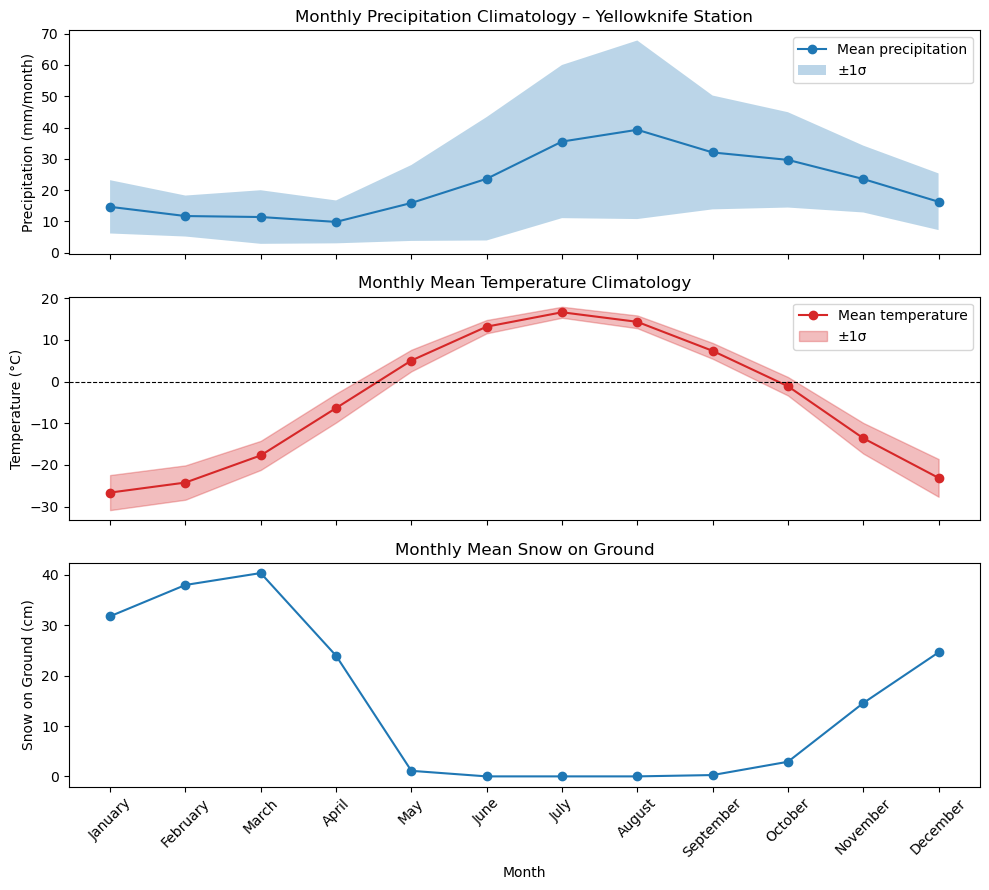

In [11]:
months = monthly_climatology["month"]
labels = monthly_climatology["month_name"]

# Extract variables
precip_mean = monthly_climatology["precip_mean_mm"]
precip_std = monthly_climatology["precip_std_mm"]

temp_mean = monthly_climatology["temp_mean_C"]
temp_std = monthly_climatology["temp_std_C"]

snow_mean = monthly_climatology["snow_mean_cm"]

# Create stacked subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# --- Precipitation ---
axes[0].plot(months, precip_mean, marker="o", label="Mean precipitation")
axes[0].fill_between(
    months,
    precip_mean - precip_std,
    precip_mean + precip_std,
    alpha=0.3,
    label="±1σ"
)
axes[0].set_ylabel("Precipitation (mm/month)")
axes[0].set_title("Monthly Precipitation Climatology – Yellowknife Station")
axes[0].legend()

# --- Temperature ---
axes[1].plot(months, temp_mean, marker="o", color="tab:red", label="Mean temperature")
axes[1].fill_between(
    months,
    temp_mean - temp_std,
    temp_mean + temp_std,
    alpha=0.3,
    color="tab:red",
    label="±1σ"
)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Monthly Mean Temperature Climatology")
axes[1].legend()

# --- Snow on ground ---
axes[2].plot(months, snow_mean, marker="o", color="tab:blue")
axes[2].set_ylabel("Snow on Ground (cm)")
axes[2].set_title("Monthly Mean Snow on Ground")

# X axis (shared)
axes[2].set_xticks(months)
axes[2].set_xticklabels(labels, rotation=45)
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.show()

### Save to file

In [9]:
output_climatology = resolve_output_path(
    "data/processed/monthly_station_climatology.csv"
)

monthly_climatology.to_csv(output_climatology, index=False)

print(f"Saved monthly climatology to:\n{output_climatology}")

Saved monthly climatology to:
C:\Users\alex.huang\repos\pcic-climate-extract\data\processed\monthly_station_climatology.csv


In [10]:
output_by_year = resolve_output_path(
    "data/processed/monthly_station_by_year.csv"
)

monthly_by_year.to_csv(output_by_year, index=False)